In [1]:
import os
import cv2
import numpy as np
import glob
import random
import joblib
import xml.etree.ElementTree as ET
from sklearn.svm import LinearSVC
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from imutils.object_detection import non_max_suppression

# --- PATH CONFIGURATION ---
# Adjust these if your folder name changes
BASE_PATH = r"..\data"
TRAIN_IMG_PATH = os.path.join(BASE_PATH, "Train", "JPEGImages")
TRAIN_ANNOT_PATH = os.path.join(BASE_PATH, "Train", "Annotations")
TEST_IMG_PATH = os.path.join(BASE_PATH, "Test", "JPEGImages")

# --- HOG PARAMETERS ---
# These must remain consistent throughout training and detection
WIN_SIZE = (64, 128)  # (width, height)
BLOCK_SIZE = (16, 16)
BLOCK_STRIDE = (8, 8)
CELL_SIZE = (8, 8)
NBINS = 9

print(f"[INFO] Configuration set. Training images located at: {TRAIN_IMG_PATH}")

[INFO] Configuration set. Training images located at: ..\data\Train\JPEGImages


In [2]:
# Initialize OpenCV's HOG Descriptor
hog_desc = cv2.HOGDescriptor(WIN_SIZE, BLOCK_SIZE, BLOCK_STRIDE, CELL_SIZE, NBINS)

def get_hog_features(img):
    """Computes HOG features for a specific 64x128 image patch."""
    if img.shape[:2] != (WIN_SIZE[1], WIN_SIZE[0]):
        img = cv2.resize(img, WIN_SIZE)
    features = hog_desc.compute(img)
    return features.flatten()

def compute_iou(boxA, boxB):
    """Calculates Intersection over Union (IoU) to check overlap."""
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    # Avoid division by zero
    union = float(boxAArea + boxBArea - interArea)
    if union == 0: return 0
    
    return interArea / union

def check_overlap_with_list(candidate_box, ground_truth_boxes):
    """Returns True if candidate_box overlaps significantly with any ground truth."""
    x, y, w, h = candidate_box
    candidate_rect = [x, y, x+w, y+h] # Convert to xmin, ymin, xmax, ymax
    
    for gt_box in ground_truth_boxes:
        # gt_box is already xmin, ymin, xmax, ymax
        if compute_iou(candidate_rect, gt_box) > 0.1: 
            return True
    return False

In [3]:
def load_dataset():
    positive_patches = []
    negative_patches = []
    
    image_paths = glob.glob(os.path.join(TRAIN_IMG_PATH, "*.png"))
    print(f"[INFO] Processing {len(image_paths)} training images...")

    for i, img_path in enumerate(image_paths):
        filename = os.path.basename(img_path)
        xml_path = os.path.join(TRAIN_ANNOT_PATH, os.path.splitext(filename)[0] + ".xml")
        
        img = cv2.imread(img_path)
        if img is None: continue
        h_img, w_img = img.shape[:2]
        
        ground_truth_boxes = [] # Store [xmin, ymin, xmax, ymax]
        
        # 1. LOAD POSITIVES (People)
        if os.path.exists(xml_path):
            tree = ET.parse(xml_path)
            root = tree.getroot()
            for obj in root.findall("object"):
                name = obj.find("name").text.lower()
                if "person" in name or "pedestrian" in name:
                    bndbox = obj.find("bndbox")
                    xmin = int(float(bndbox.find("xmin").text))
                    ymin = int(float(bndbox.find("ymin").text))
                    xmax = int(float(bndbox.find("xmax").text))
                    ymax = int(float(bndbox.find("ymax").text))
                    
                    ground_truth_boxes.append([xmin, ymin, xmax, ymax])
                    
                    # Crop and save positive
                    roi = img[ymin:ymax, xmin:xmax]
                    if roi.size > 0:
                        roi_resized = cv2.resize(roi, WIN_SIZE)
                        positive_patches.append(roi_resized)
                        
                        # --- AUGMENTATION: Horizontal Flip ---
                        positive_patches.append(cv2.flip(roi_resized, 1))

        # 2. LOAD RANDOM NEGATIVES (Background)
        # Try to find 5 random spots per image that are NOT people
        num_negatives = 5
        attempts = 0
        collected = 0
        
        while collected < num_negatives and attempts < 50:
            attempts += 1
            if w_img < WIN_SIZE[0] or h_img < WIN_SIZE[1]: break
            
            x_rand = random.randint(0, w_img - WIN_SIZE[0])
            y_rand = random.randint(0, h_img - WIN_SIZE[1])
            
            # Only use if it doesn't overlap with a person
            if not check_overlap_with_list((x_rand, y_rand, WIN_SIZE[0], WIN_SIZE[1]), ground_truth_boxes):
                patch = img[y_rand:y_rand+WIN_SIZE[1], x_rand:x_rand+WIN_SIZE[0]]
                negative_patches.append(patch)
                collected += 1

    return positive_patches, negative_patches

# Run the loader
print("[INFO] Loading Dataset...")
pos_imgs, neg_imgs = load_dataset()
print(f"[RESULT] Positive Samples: {len(pos_imgs)}")
print(f"[RESULT] Negative Samples: {len(neg_imgs)}")

[INFO] Loading Dataset...
[INFO] Processing 614 training images...
[RESULT] Positive Samples: 2480
[RESULT] Negative Samples: 3070


In [4]:
print("[INFO] Extracting features...")
X_pos = [get_hog_features(img) for img in pos_imgs]
X_neg = [get_hog_features(img) for img in neg_imgs]

# Stack data
X = np.vstack((X_pos, X_neg))
# Create labels: 1 for person, 0 for background
y = np.hstack((np.ones(len(X_pos)), np.zeros(len(X_neg))))

# Shuffle data
X, y = shuffle(X, y, random_state=42)

print(f"[INFO] Training Initial SVM on {len(X)} samples...")
model = LinearSVC(C=0.01, max_iter=5000, class_weight='balanced')
model.fit(X, y)
print("[INFO] Initial Training Complete.")

[INFO] Extracting features...
[INFO] Training Initial SVM on 5550 samples...
[INFO] Initial Training Complete.


In [5]:
print("[INFO] Starting Hard Negative Mining...")

hard_negatives = []
mine_count = 0

# Convert sklearn model weights to OpenCV format
svm_detector = np.zeros((model.coef_.shape[1] + 1,), dtype=np.float32)
svm_detector[:-1] = model.coef_.reshape(-1)
# Robust intercept handling
if isinstance(model.intercept_, (list, np.ndarray)):
    svm_detector[-1] = model.intercept_[0]
else:
    svm_detector[-1] = model.intercept_

hog_desc.setSVMDetector(svm_detector)

# Re-scan a subset of training images to find false positives
image_paths = glob.glob(os.path.join(TRAIN_IMG_PATH, "*.png"))
random.shuffle(image_paths) 

# Limit to 500 images to save time (increase if you have a powerful PC)
for i, img_path in enumerate(image_paths[:500]): 
    img = cv2.imread(img_path)
    if img is None: continue
    
    # Load ground truth again to verify mistakes
    filename = os.path.basename(img_path)
    xml_path = os.path.join(TRAIN_ANNOT_PATH, os.path.splitext(filename)[0] + ".xml")
    gt_boxes = []
    if os.path.exists(xml_path):
        tree = ET.parse(xml_path)
        for obj in tree.findall(".//object"):
             if "person" in obj.find("name").text.lower():
                bndbox = obj.find("bndbox")
                gt_boxes.append([
                    int(float(bndbox.find("xmin").text)),
                    int(float(bndbox.find("ymin").text)),
                    int(float(bndbox.find("xmax").text)),
                    int(float(bndbox.find("ymax").text))
                ])

    # Run detection with Low threshold to catch mistakes
    (rects, weights) = hog_desc.detectMultiScale(img, winStride=(8, 8), padding=(8, 8), scale=1.05, hitThreshold=0)
    
    # USE rx, ry TO AVOID OVERWRITING GLOBAL 'y'
    for (rx, ry, rw, rh) in rects:
        # If detection does NOT overlap with a real person, it is a False Positive
        if not check_overlap_with_list((rx, ry, rw, rh), gt_boxes):
            patch = img[ry:ry+rh, rx:rx+rw]
            if patch.size > 0:
                patch_resized = cv2.resize(patch, WIN_SIZE)
                hard_negatives.append(get_hog_features(patch_resized))
                mine_count += 1

print(f"[RESULT] Mined {mine_count} Hard Negatives.")

[INFO] Starting Hard Negative Mining...
[RESULT] Mined 9375 Hard Negatives.


In [6]:
if len(hard_negatives) > 0:
    print(f"[INFO] Found {len(hard_negatives)} Hard Negatives. Preparing to retrain...")
    
    # 1. Prepare Hard Negative Data
    X_hard = np.array(hard_negatives)
    y_hard = np.zeros(len(hard_negatives)) # Label 0 for background
    
    # 2. CRITICAL FIX: Flatten 'y' to ensure it merges correctly
    y = y.ravel() 
    
    # 3. Merge Arrays Safely
    X_final = np.vstack((X, X_hard))
    y_final = np.concatenate([y, y_hard])
    
    print(f"[DEBUG] X_final shape: {X_final.shape}")
    print(f"[DEBUG] y_final shape: {y_final.shape}")
    
    # 4. Shuffle
    X_final, y_final = shuffle(X_final, y_final, random_state=42)
    
    # 5. Retrain
    print("[INFO] Retraining Final Model...")
    final_model = LinearSVC(C=0.01, max_iter=10000, class_weight='balanced')
    final_model.fit(X_final, y_final)
    print("[INFO] Final Model Trained Successfully.")

else:
    print("[INFO] No hard negatives found. Using initial model.")
    final_model = model

[INFO] Found 9375 Hard Negatives. Preparing to retrain...
[DEBUG] X_final shape: (14925, 3780)
[DEBUG] y_final shape: (14925,)
[INFO] Retraining Final Model...
[INFO] Final Model Trained Successfully.


In [7]:
print("[INFO] Saving model...")
joblib.dump(final_model, 'pedestrian_svm_hard_mined.pkl')

# Verify shape for OpenCV
coef_shape = final_model.coef_.shape
if isinstance(final_model.intercept_, (list, np.ndarray)):
    intercept = final_model.intercept_[0]
else:
    intercept = final_model.intercept_

print(f"Model saved. Coefficients: {coef_shape}, Intercept: {intercept}")
print("You can now run the detection script using 'pedestrian_svm_hard_mined.pkl'")

[INFO] Saving model...
Model saved. Coefficients: (1, 3780), Intercept: -0.43882228961713104
You can now run the detection script using 'pedestrian_svm_hard_mined.pkl'


[INFO] Testing on: person_and_bike_190.png


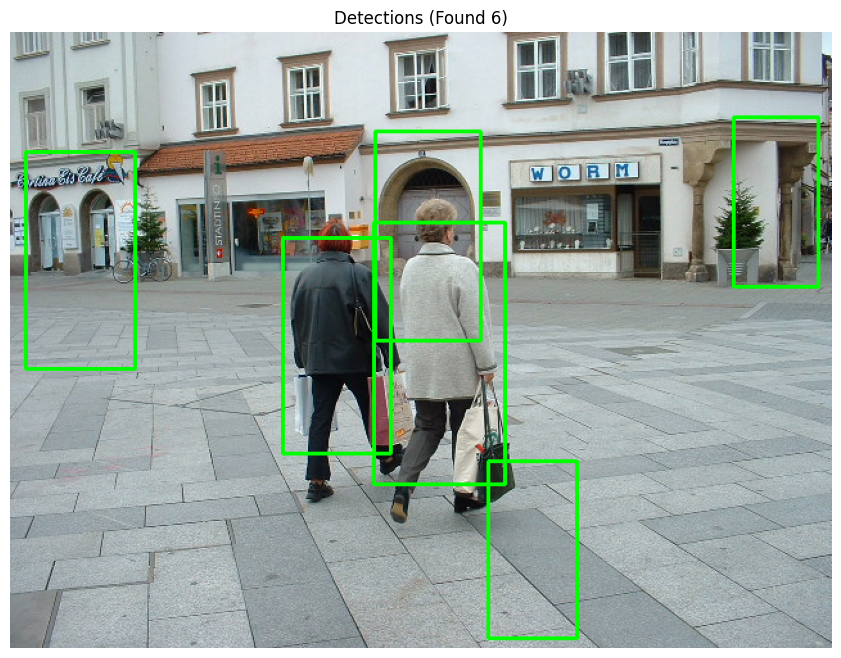

In [8]:
# Load a random test image
test_files = glob.glob(os.path.join(TEST_IMG_PATH, "*.png"))

if test_files:
    test_img_path = random.choice(test_files)
    test_img = cv2.imread(test_img_path)
    
    # Resize for better display if needed
    if test_img.shape[1] > 800:
        scale = 800 / test_img.shape[1]
        test_img = cv2.resize(test_img, None, fx=scale, fy=scale)
    
    # Setup detector
    svm_detector = np.zeros((final_model.coef_.shape[1] + 1,), dtype=np.float32)
    svm_detector[:-1] = final_model.coef_.reshape(-1)
    if isinstance(final_model.intercept_, (list, np.ndarray)):
        svm_detector[-1] = final_model.intercept_[0]
    else:
        svm_detector[-1] = final_model.intercept_
        
    hog_desc.setSVMDetector(svm_detector)
    
    print(f"[INFO] Testing on: {os.path.basename(test_img_path)}")
    
    # Detect
    (rects, weights) = hog_desc.detectMultiScale(test_img, winStride=(4, 4), padding=(8, 8), scale=1.05)
    
    # Apply NMS
    rects_array = np.array([[x, y, x + w, y + h] for (x, y, w, h) in rects])
    pick = non_max_suppression(rects_array, probs=None, overlapThresh=0.65)
    
    # Draw boxes
    for (xA, yA, xB, yB) in pick:
        cv2.rectangle(test_img, (xA, yA), (xB, yB), (0, 255, 0), 2)
        
    # Show using Matplotlib
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Detections (Found {len(pick)})")
    plt.axis("off")
    plt.show()
else:
    print("No test images found.")

[INFO] Loading model from pedestrian_svm_hard_mined.pkl...
[INFO] Found 288 test images.


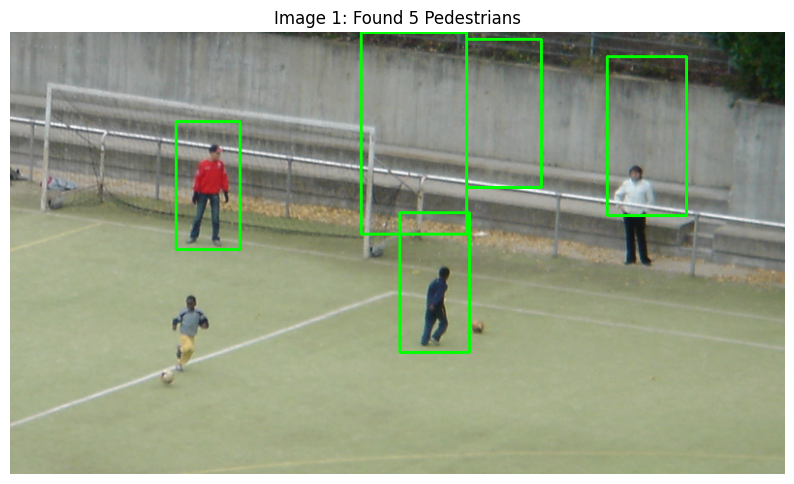

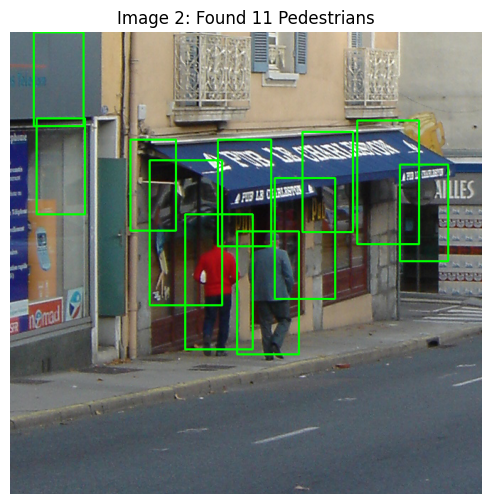

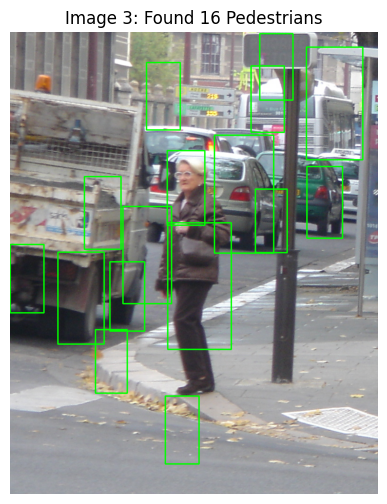

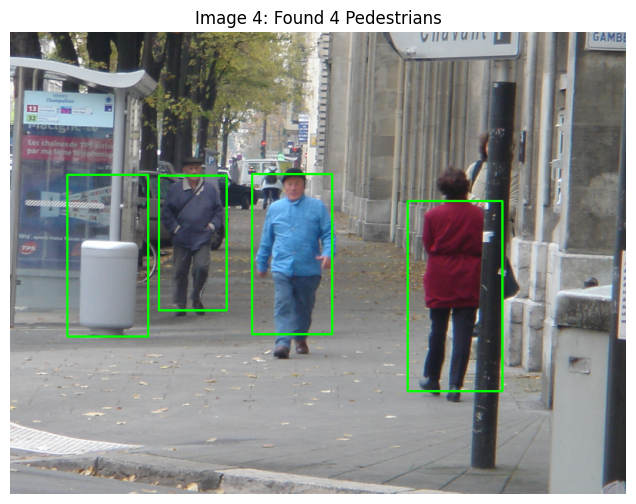

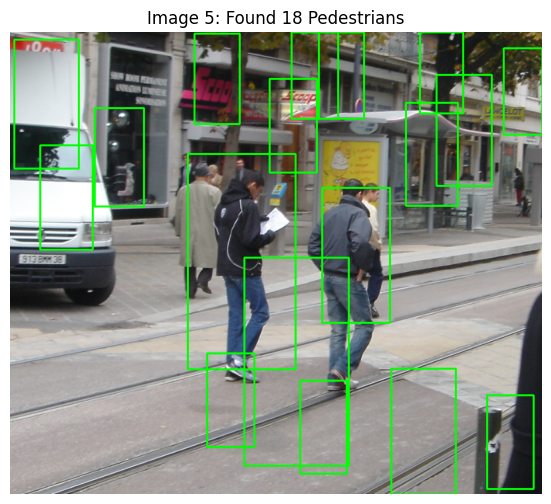

[INFO] Showing first 5 results. Run the loop again to see more.


In [10]:
import cv2
import joblib
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
from imutils.object_detection import non_max_suppression

# --- CONFIGURATION ---
BASE_PATH = r"../data"
TEST_IMG_PATH = os.path.join(BASE_PATH, "Test", "JPEGImages")
MODEL_PATH = "pedestrian_svm_hard_mined.pkl"  # Ensure this matches your saved filename

# MUST MATCH TRAINING PARAMS EXACTLY
WIN_SIZE = (64, 128)
BLOCK_SIZE = (16, 16)
BLOCK_STRIDE = (8, 8)
CELL_SIZE = (8, 8)
NBINS = 9

def load_svm_for_opencv(model_path):
    print(f"[INFO] Loading model from {model_path}...")
    if not os.path.exists(model_path):
        print(f"[ERROR] Model file not found at {model_path}")
        return None

    model = joblib.load(model_path)
    
    # Convert weights to OpenCV format
    # OpenCV expects a single flattened array: [coefs, intercept]
    svm_detector = np.zeros((model.coef_.shape[1] + 1,), dtype=np.float32)
    svm_detector[:-1] = model.coef_.reshape(-1)
    
    # Robust intercept handling (Fixes the array vs float crash)
    if isinstance(model.intercept_, (list, np.ndarray)):
        svm_detector[-1] = model.intercept_[0]
    else:
        svm_detector[-1] = model.intercept_
    
    return svm_detector

def detect_and_show():
    # 1. Setup HOG
    hog = cv2.HOGDescriptor(WIN_SIZE, BLOCK_SIZE, BLOCK_STRIDE, CELL_SIZE, NBINS)
    
    # 2. Inject trained weights
    svm_detector = load_svm_for_opencv(MODEL_PATH)
    if svm_detector is None: return
    hog.setSVMDetector(svm_detector)
    
    # 3. Get list of images
    image_paths = glob.glob(os.path.join(TEST_IMG_PATH, "*.png"))
    print(f"[INFO] Found {len(image_paths)} test images.")
    
    if len(image_paths) == 0:
        print("[WARNING] No images found. Check your path.")
        return

    # Loop through images
    for i, image_path in enumerate(image_paths):
        # Read Image
        image = cv2.imread(image_path)
        if image is None: continue
        
        # Resize large images for speed (keep aspect ratio)
        (h, w) = image.shape[:2]
        if w > 800:
            scale = 800 / w
            image = cv2.resize(image, (800, int(h * scale)))

        # 4. Detect People
        # winStride: (4,4) is accurate, (8,8) is faster
        # hitThreshold: 0 is standard. Lower (e.g. -0.5) finds more people but more noise.
        (rects, weights) = hog.detectMultiScale(
            image, 
            winStride=(4, 4), 
            padding=(8, 8), 
            scale=1.05,
            hitThreshold=0 
        )

        # 5. Non-Maximum Suppression (NMS)
        # Merges overlapping boxes into a single clean box
        rects_array = np.array([[x, y, x + w, y + h] for (x, y, w, h) in rects])
        pick = non_max_suppression(rects_array, probs=None, overlapThresh=0.65)

        # Draw boxes (Green)
        for (xA, yA, xB, yB) in pick:
            cv2.rectangle(image, (xA, yA), (xB, yB), (0, 255, 0), 2)
        
        # Show result using Matplotlib (Best for Notebooks)
        # Convert BGR (OpenCV standard) to RGB (Matplotlib standard)
        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title(f"Image {i+1}: Found {len(pick)} Pedestrians")
        plt.axis("off")
        plt.show()

        # Stop after 5 images to prevent flooding the notebook
        if i >= 4:
            print("[INFO] Showing first 5 results. Run the loop again to see more.")
            break

if __name__ == "__main__":
    detect_and_show()